# Layer 4 — LightGBM Risk Model Diagnostics
**Bengaluru Traffic Intelligence Platform (BTIP)**

This notebook validates the Layer 4 risk pipeline trained by
`backend/models/risk/lgbm_risk.py`, `xgb_challenger.py`, `calibration.py`,
and `shap_explainer.py`. It covers:

1. Time-series CV scores — LightGBM vs XGBoost
2. Feature importance (gain)
3. SHAP beeswarm — global explanation
4. Platt calibration curve (raw count to 0-100 Risk Score)
5. Reliability check — predicted score vs actual violation rate

**Prerequisite:** `lgbm_risk.train()`, `xgb_challenger.train()`, and
`calibration.train_calibrator()` must have already been run, so that
saved artefacts exist under `models/saved/risk/`.

In [2]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import shap

# Make `backend.*` importable when running from notebooks/
PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "backend").exists() is False else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from backend.models.risk import lgbm_risk, xgb_challenger, shap_explainer, calibration

plt.rcParams["figure.facecolor"] = "#0B0E14"
plt.rcParams["axes.facecolor"] = "#141820"
plt.rcParams["axes.edgecolor"] = "#666B7A"
plt.rcParams["axes.labelcolor"] = "#E8E8E8"
plt.rcParams["text.color"] = "#E8E8E8"
plt.rcParams["xtick.color"] = "#E8E8E8"
plt.rcParams["ytick.color"] = "#E8E8E8"
plt.rcParams["figure.figsize"] = (7, 5)

## 1. Load feature store + trained artefacts

In [3]:
df = lgbm_risk.load_feature_store()
print(f"Raw rows: {len(df):,}  |  columns: {df.width}")

df_agg = lgbm_risk._build_zone_windows(df)
print(f"Aggregated zone-windows: {len(df_agg):,}")

model, encoders, feature_cols = lgbm_risk.load_model()
df_agg_enc, _ = lgbm_risk._encode_categoricals(df_agg, encoders=encoders, fit=False)

X = df_agg_enc[feature_cols].to_numpy()
y = df_agg_enc[lgbm_risk.TARGET].to_numpy().astype(float)
print(f"Feature matrix: {X.shape}")

Raw rows: 298,282  |  columns: 49
Aggregated zone-windows: 232,482
Feature matrix: (232482, 16)


## 2. Cross-validation scores — LightGBM vs XGBoost

Both models use `TimeSeriesSplit` (expanding window) — validation folds
never precede training folds, so there is no future leakage.

In [5]:
lgbm_cv = lgbm_risk.cross_validate(df_agg_enc, feature_cols)
xgb_cv = xgb_challenger.cross_validate_xgb(df_agg_enc, feature_cols)

cv_table = pl.DataFrame({
    "fold": [m["fold"] for m in lgbm_cv["folds"]],
    "lgbm_mae": [round(m["mae"], 2) for m in lgbm_cv["folds"]],
    "xgb_mae": [round(m["mae"], 2) for m in xgb_cv["folds"]],
})
cv_table

C:\Users\Acer\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Acer\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Acer\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Acer\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Acer\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegress

TypeError: XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'

NameError: name 'xgb_cv' is not defined

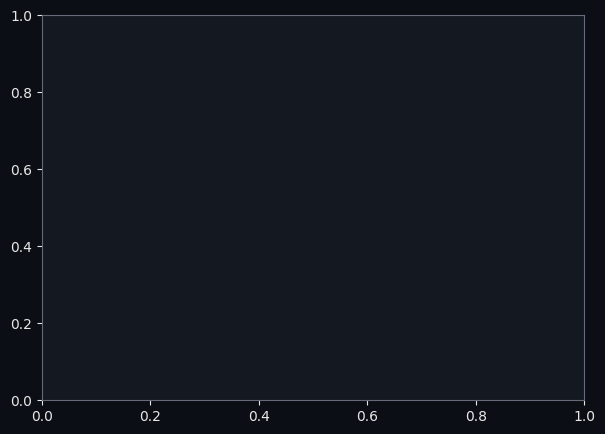

In [6]:
fig, ax = plt.subplots()
ax.bar(["LightGBM", "XGBoost"], [lgbm_cv["mean_mae"], xgb_cv["mean_mae"]],
       color=["#00D4FF", "#FFB020"])
ax.axhline(15, color="#FF4444", linestyle="--", linewidth=1, label="Target MAE = 15")
ax.set_ylabel("Mean CV MAE (violations / 4h window)")
ax.set_title("LightGBM vs XGBoost — 5-fold Time-Series CV")
ax.legend()
plt.tight_layout()
plt.show()

print(f"LightGBM mean MAE: {lgbm_cv['mean_mae']:.2f}  (target < 15)")
print(f"XGBoost  mean MAE: {xgb_cv['mean_mae']:.2f}")

## 3. Feature importance (LightGBM gain)

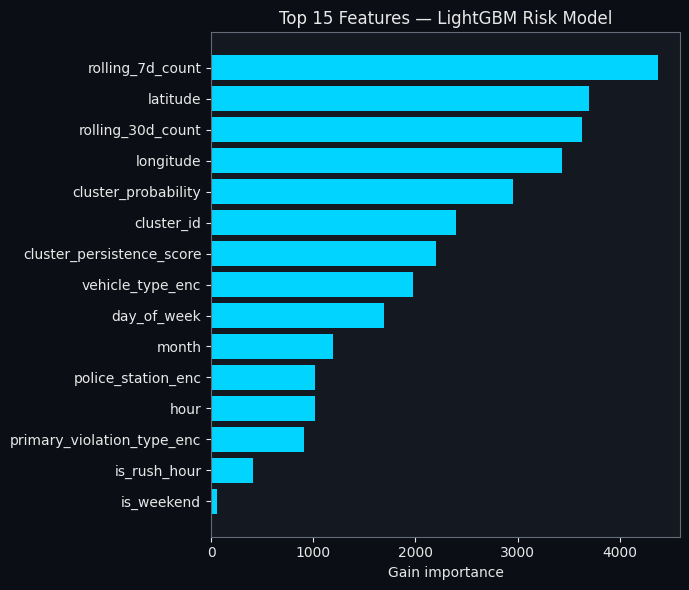

In [7]:
fi = lgbm_risk.feature_importance(model, feature_cols, top_n=15)

features = [f["feature"] for f in fi][::-1]
importances = [f["importance"] for f in fi][::-1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(features, importances, color="#00D4FF")
ax.set_xlabel("Gain importance")
ax.set_title("Top 15 Features — LightGBM Risk Model")
plt.tight_layout()
plt.show()

## 4. SHAP beeswarm — global explanation

Sampled to 1,000 rows for speed; full-dataset SHAP is computed lazily
per-request in `backend/api/routes/risk.py`.

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
 96%|=================== | 958/1000 [00:22<00:00]       

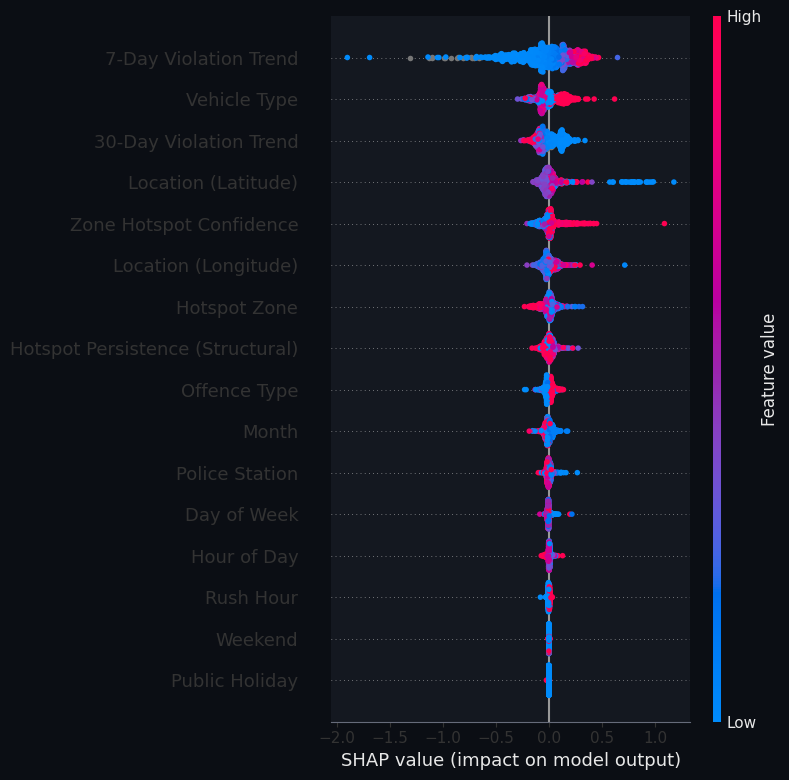

In [8]:
explainer = shap_explainer.build_explainer(model, X_background=X)

sample_size = min(1000, X.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)
X_sample = X[sample_idx]

shap_values = explainer.shap_values(X_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

readable_cols = [shap_explainer._readable(c) for c in feature_cols]
shap.summary_plot(shap_values, X_sample, feature_names=readable_cols, show=True)

## 5. Calibration curve — raw count to Risk Score (0-100)

Platt sigmoid fitted on out-of-fold predictions in
`calibration.fit_calibrator_from_cv`. The curve should saturate near the
training set's 95th-percentile violation count (`p95`), by construction.

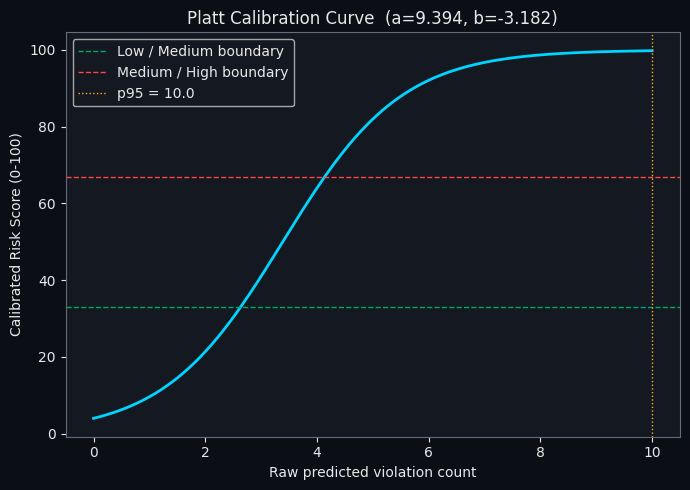

In [9]:
calibrator = calibration.load_calibrator()

raw_range = np.linspace(0, max(float(np.percentile(y, 99)), 10), 200)
scores = calibrator.predict_score(raw_range)

fig, ax = plt.subplots()
ax.plot(raw_range, scores, color="#00D4FF", linewidth=2)
ax.axhline(33, color="#00A86B", linestyle="--", linewidth=1, label="Low / Medium boundary")
ax.axhline(67, color="#FF4444", linestyle="--", linewidth=1, label="Medium / High boundary")
ax.axvline(calibrator.p95, color="#FFB020", linestyle=":", linewidth=1,
           label=f"p95 = {calibrator.p95:.1f}")
ax.set_xlabel("Raw predicted violation count")
ax.set_ylabel("Calibrated Risk Score (0-100)")
ax.set_title(f"Platt Calibration Curve  (a={calibrator.a:.3f}, b={calibrator.b:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Reliability check — predicted score vs actual violation rate

C:\Users\Acer\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


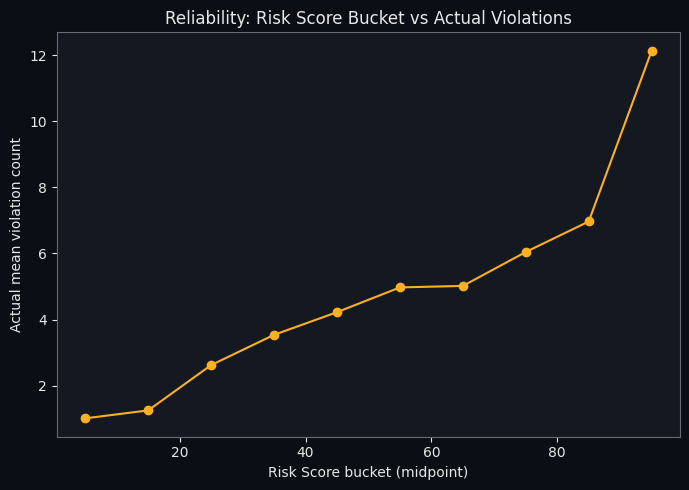

In [10]:
pred_raw = np.maximum(model.predict(X), 0)
pred_scores = calibrator.predict_score(pred_raw)

bins = np.arange(0, 110, 10)
bin_idx = np.digitize(pred_scores, bins) - 1

bin_centers, bin_actual_mean = [], []
for b in range(len(bins) - 1):
    mask = bin_idx == b
    if mask.sum() > 0:
        bin_actual_mean.append(float(y[mask].mean()))
        bin_centers.append((bins[b] + bins[b + 1]) / 2)

fig, ax = plt.subplots()
ax.plot(bin_centers, bin_actual_mean, marker="o", color="#FFB020")
ax.set_xlabel("Risk Score bucket (midpoint)")
ax.set_ylabel("Actual mean violation count")
ax.set_title("Reliability: Risk Score Bucket vs Actual Violations")
plt.tight_layout()
plt.show()

## Summary

- **CV MAE** — compare LightGBM vs XGBoost against the Layer 4
  verification target (< 15 violations / 4h window).
- **Feature importance** — confirms which engineered features (rolling
  counts, rush-hour, cluster persistence) actually drive predictions.
- **SHAP beeswarm** — global view of direction + magnitude per feature;
  the same `TreeExplainer` powers the per-request explanations returned
  by `GET /api/v1/risk`.
- **Calibration curve** — sanity-checks that the Platt sigmoid saturates
  near `p95` and that the Low/Medium/High thresholds (33 / 67) land in a
  sensible place on the raw-count axis.
- **Reliability check** — a monotonically increasing line confirms the
  calibrated score is actually ordering zones correctly, not just
  compressing everything into the middle.